In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
X_test = joblib.load("../models/X_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

print(X_test.shape)
print(y_test.shape)

(118108, 477)
(118108,)


In [4]:
models = {

    "Logistic Regression":
    joblib.load("../models/logistic_regression.pkl"),

    "Decision Tree":
    joblib.load("../models/decision_tree.pkl"),

    "Random Forest":
    joblib.load("../models/random_forest.pkl"),

    "XGBoost":
    joblib.load("../models/xgboost.pkl"),

    "LightGBM":
    joblib.load("../models/lightgbm.pkl")
}

In [5]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    results.append({

        "Model":name,

        "Accuracy":
        accuracy_score(y_test,y_pred),

        "Precision":
        precision_score(y_test,y_pred),

        "Recall":
        recall_score(y_test,y_pred),

        "F1":
        f1_score(y_test,y_pred),

        "ROC_AUC":
        roc_auc_score(y_test,y_prob),

        "PR_AUC":
        average_precision_score(y_test,y_prob)

    })

In [6]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC_AUC",
    ascending=False,
    inplace=True
)

results_df.reset_index(drop=True,inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.982084,0.939434,0.521655,0.670815,0.955392,0.772377
1,Random Forest,0.982406,0.897178,0.561578,0.690774,0.953972,0.774408
2,LightGBM,0.979790,0.917703,0.464070,0.616423,0.945420,0.727555
3,Decision Tree,0.969105,0.557237,0.570046,0.563569,0.776811,0.332697
4,Logistic Regression,0.787220,0.094289,0.590370,0.162607,0.742993,0.104851


In [7]:
results_df.to_csv(
    "../models/model_comparison.csv",
    index=False
)

In [8]:
for name,model in models.items():

    print("="*70)

    print(name)

    y_pred=model.predict(X_test)

    print(classification_report(
        y_test,
        y_pred
    ))

Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.79      0.88    113975
           1       0.09      0.59      0.16      4133

    accuracy                           0.79    118108
   macro avg       0.54      0.69      0.52    118108
weighted avg       0.95      0.79      0.85    118108

Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    113975
           1       0.56      0.57      0.56      4133

    accuracy                           0.97    118108
   macro avg       0.77      0.78      0.77    118108
weighted avg       0.97      0.97      0.97    118108

Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.90      0.56      0.69      4133

    accuracy                           0.98    118108
   macro avg       0.94      0.78      0.84    118108
weighted avg       0.98   

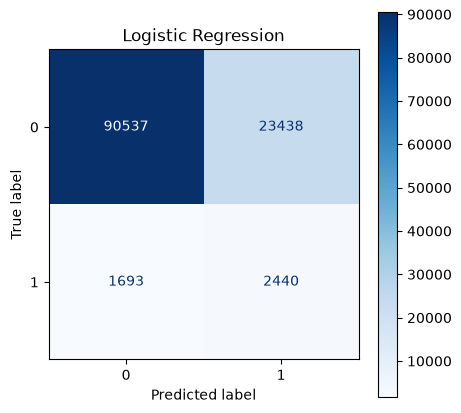

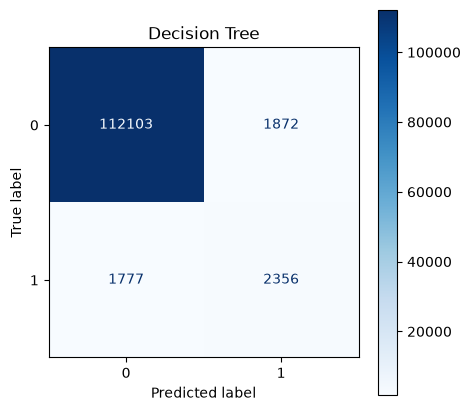

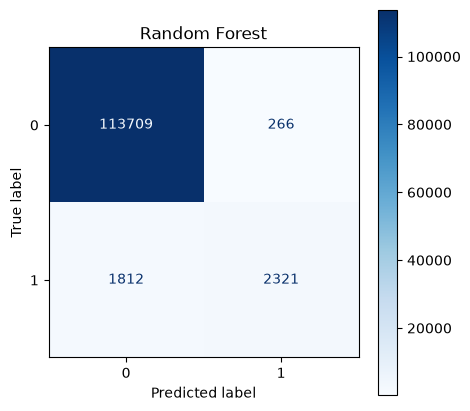

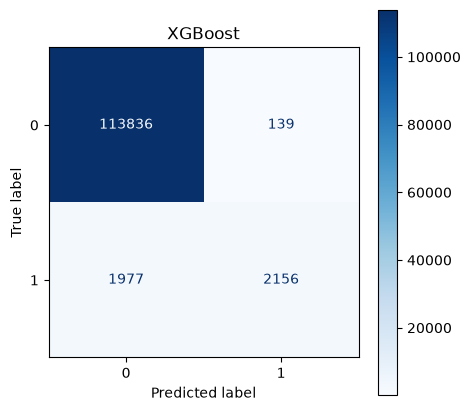

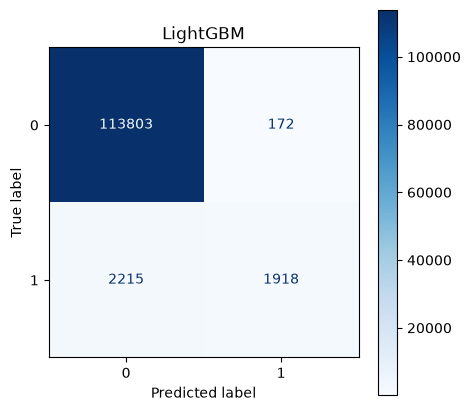

In [9]:
for name,model in models.items():

    fig,ax=plt.subplots(figsize=(5,5))

    y_pred=model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        y_pred,

        cmap="Blues",

        ax=ax

    )

    plt.title(name)

    plt.show()

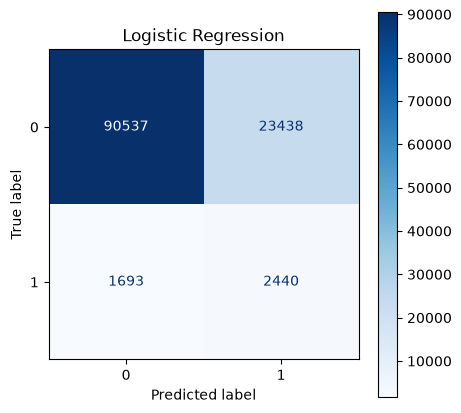

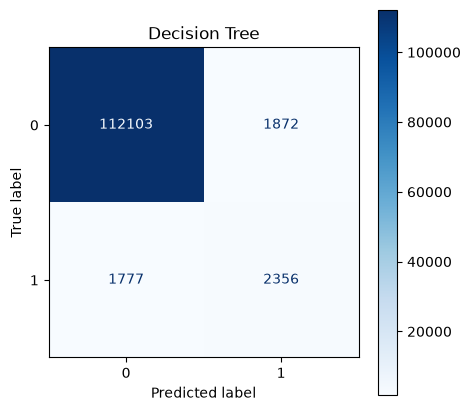

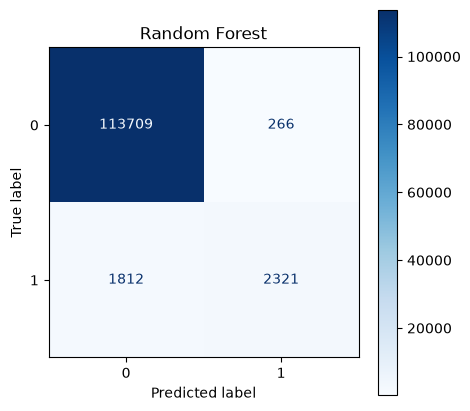

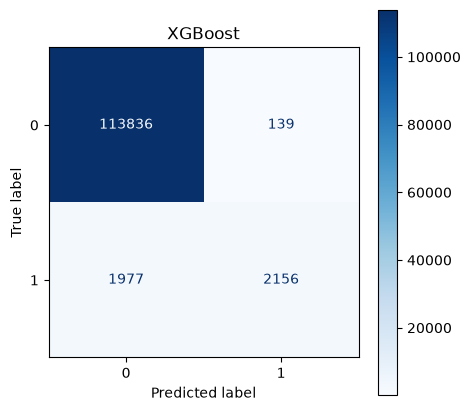

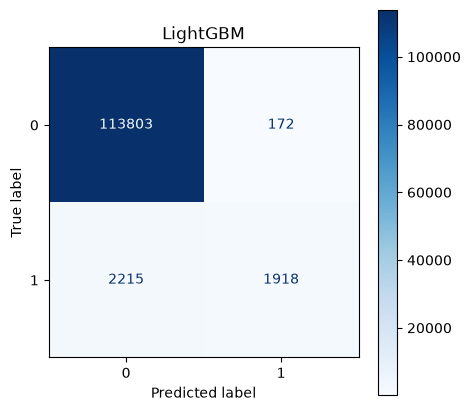

In [10]:
for name,model in models.items():

    fig,ax=plt.subplots(figsize=(5,5))

    y_pred=model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        y_pred,

        cmap="Blues",

        ax=ax

    )

    plt.title(name)

    plt.show()

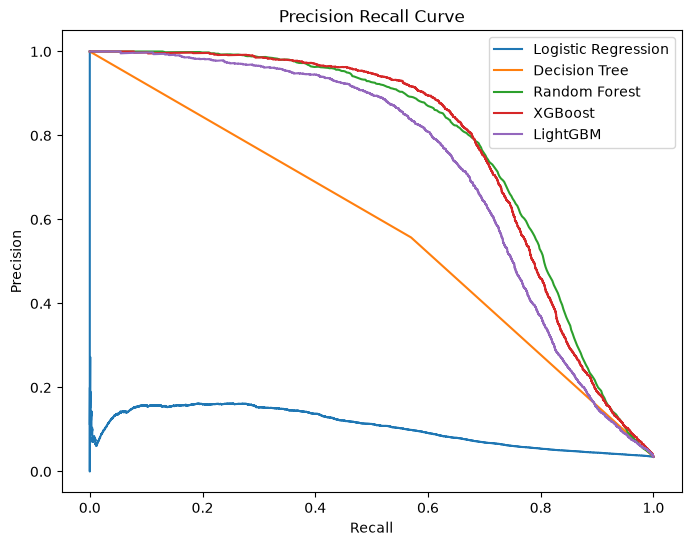

In [11]:
plt.figure(figsize=(8,6))

for name,model in models.items():

    y_prob=model.predict_proba(X_test)[:,1]

    precision,recall,_=precision_recall_curve(

        y_test,

        y_prob

    )

    plt.plot(

        recall,

        precision,

        label=name

    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

plt.show()

In [12]:
best_tree_models = {

    "Random Forest":
    models["Random Forest"],

    "XGBoost":
    models["XGBoost"],

    "LightGBM":
    models["LightGBM"]

}

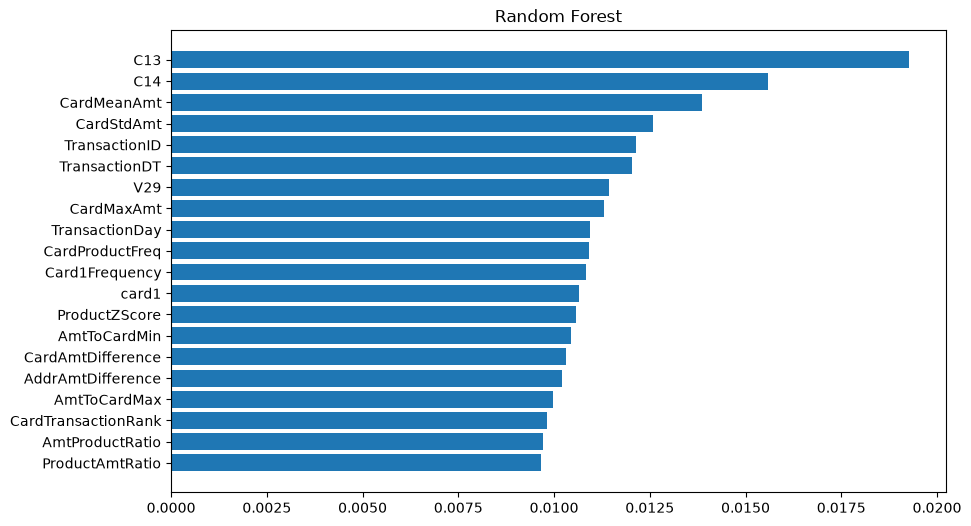

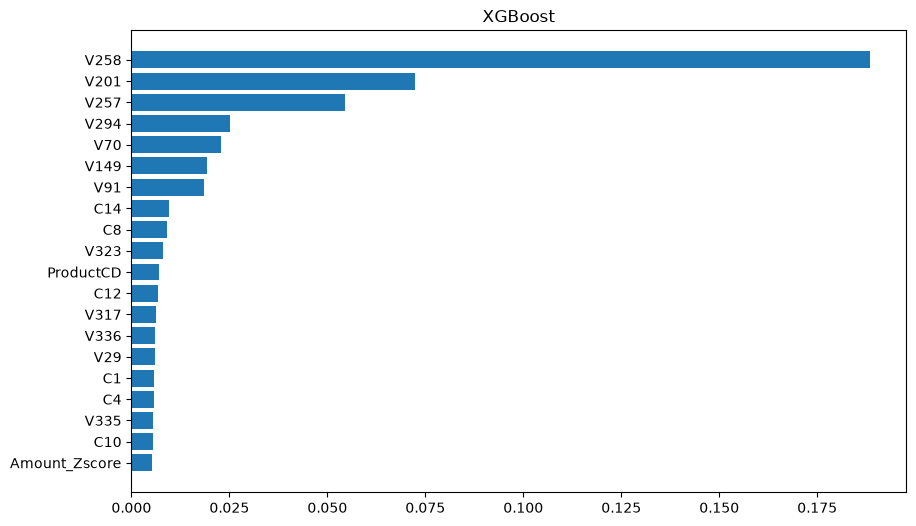

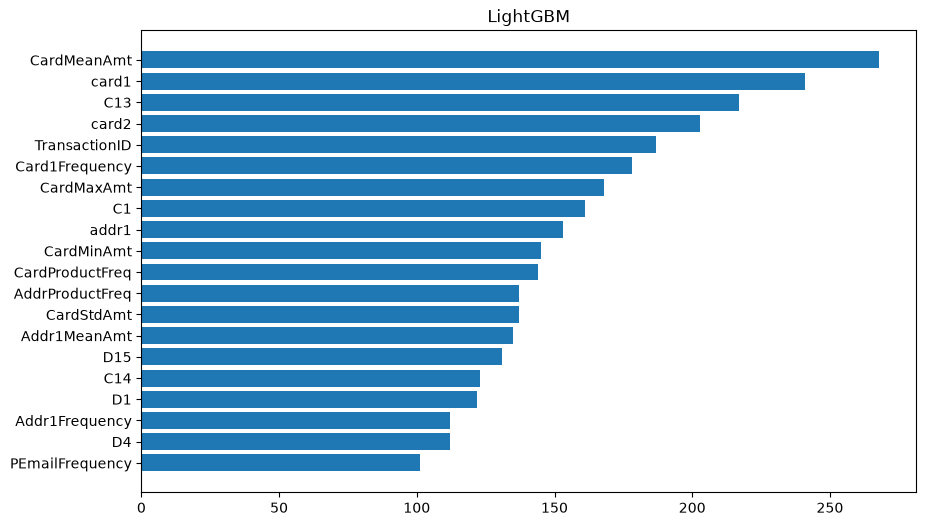

In [13]:
for name,model in best_tree_models.items():

    importance=pd.DataFrame({

        "Feature":X_test.columns,

        "Importance":model.feature_importances_

    })

    importance.sort_values(

        by="Importance",

        ascending=False,

        inplace=True

    )

    plt.figure(figsize=(10,6))

    plt.barh(

        importance["Feature"][:20],

        importance["Importance"][:20]

    )

    plt.gca().invert_yaxis()

    plt.title(name)

    plt.show()

In [14]:
best_model_name = results_df.iloc[0]["Model"]

print(best_model_name)

XGBoost


In [15]:
best_model=models[best_model_name]

joblib.dump(

    best_model,

    "../models/best_model.pkl"

)

print("Best model saved.")

Best model saved.


In [16]:
print("="*60)

print("MODEL COMPARISON")

print("="*60)

display(results_df)

print()

print(f"Selected Model : {best_model_name}")

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.982084,0.939434,0.521655,0.670815,0.955392,0.772377
1,Random Forest,0.982406,0.897178,0.561578,0.690774,0.953972,0.774408
2,LightGBM,0.979790,0.917703,0.464070,0.616423,0.945420,0.727555
3,Decision Tree,0.969105,0.557237,0.570046,0.563569,0.776811,0.332697
4,Logistic Regression,0.787220,0.094289,0.590370,0.162607,0.742993,0.104851



Selected Model : XGBoost


In [18]:
import joblib

X_train = joblib.load("../models/X_train.pkl")

In [19]:
joblib.dump(
    X_train.columns.tolist(),
    "../models/feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!
